In [ ]:
####################
## ---------
# Author: Ryan Johnson
# Lab: Risca Lab
# Date: 8/31/2026
# ----------
####################

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#####
# below will be two functions.
# one will call the other function, so you just need to put parameters in for the function named ""

In [4]:
# make a function to preprocess the data and make a numpy array with the 10 chunks

def make_chunk_npy(path_to_npy_filex, trial_numberx, nrl_lengthx) :

    path_to_nrl_npy_file = path_to_npy_filex

    trial_number = trial_numberx

    nrl_length = nrl_lengthx

    basename_file = str.split(path_to_nrl_npy_file, sep = "/" )[-1]
    meta_data = str.split(basename_file, sep="_")[3:6]

    #######
    # here I will have modified code that creates the numpy array and probably saves plots to a pdf file

    # making the plot for other trials in nrl 215 (trial 3)

    # flds_215_nrl_12nucs_2kbt_3_trial_full_data = np.load('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_3_trial.npy')
    fld_loaded_data = np.load(path_to_nrl_npy_file)
    
    # looking at the shapes
    print(np.shape(fld_loaded_data))
    
    print(fld_loaded_data)
    
    # now split without randomizing
    
    nrl_split_chunks = np.array_split(fld_loaded_data, indices_or_sections= 10, axis = 0)
    
    
    # now loop through each chunk and average them
    nrl_split_chunks_avgeraged = []
    
    for x in nrl_split_chunks:
        
        averaged_chunk = np.average(x, axis = 0)
        print("this is in the for loop showing the size of the chunk \n")
        print(np.shape(averaged_chunk))
        nrl_split_chunks_avgeraged.append(averaged_chunk)
    
    
    # first look at the full averaged array
    
    
    print("\n this is the shape of the full averaged array after the for loop \n")
    
    print(np.shape(nrl_split_chunks_avgeraged))
    
    
    # then i need to plot below
    
    num_chunks = 10
    cmap = plt.colormaps['turbo']  # 'turbo' or 'rainbow' work perfectly for sequential time data
    colors = cmap(np.linspace(0, 1, num_chunks))
    
    x_axis = np.arange(50, 50 + len(nrl_split_chunks_avgeraged[0]))
    
    chunk_num = 0
    
    for x in nrl_split_chunks_avgeraged:
        
        plt.plot(x_axis, x, color = colors[chunk_num], label = "this is snapshot average number " + str(chunk_num))
        plt.title("FLD of NRL" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_" + str(meta_data[2]) +  "_trial (not randomized)")
        plt.xlabel("fragment lengths")
        plt.ylabel("frequency")
        plt.legend(fontsize = 'small')
        chunk_num +=1
    plt.savefig("FLD_of_NRL_" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_trial_" + str(meta_data[2]) + ".pdf", format = "pdf")



    # I can call the make_nrl_csv function in this function
    # just pass the chunk_npy file that is created into that function
    # and pass the trial number and nrl length also 

    # calling the other function here
    make_nrl_csv(nrl_split_chunks_avgeraged, trial_number, nrl_length, meta_data)




# now make the function to make the csv

def make_nrl_csv(nrl_chunk_npy, trial_numberx, nrl_lengthx, meta_datax) :

    # now making a csv for hera but 10 different csv's for each chunk of NRL 215

    # modifying this to make the csv where all the chunks are in one file as different columns
    
    # give the trial number
    trial_number = trial_numberx
    nrl_length = nrl_lengthx
    meta_data = meta_datax

    # need x_axis defined here
    x_axis = np.arange(50, 50 + len(nrl_chunk_npy[0]))
    
    new_df = pd.DataFrame()
    new_df['fragment_lengths'] = x_axis
    name_sample = "NRL" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_trial_" + str(trial_number)
    new_df.insert(0, "sample_name", value = name_sample) 
    
    
    
    chunk_number = 0
    for x in nrl_chunk_npy:
    
        # name_sample = "NRL215_12nucs_2kbt_trial_" + str(trial_number) #+ str(chunk_number)
    
        # new_df = pd.DataFrame()
        new_df['avg_frequency_chunk_' + str(chunk_number) ] = x
        # new_df['fragment_lengths'] = x_axis
        # new_df.insert(0, "sample_name", value = name_sample) 
        # = name_sample
    
        
        # print(new_df)
        
    
        # new_df.to_csv('./' + name_sample + ".csv", sep= ",", index=False)
    
        chunk_number += 1
    
    print(new_df)
    
    # save to a csv
    new_df.to_csv('./' + name_sample + ".csv", sep= ",", index=False)

In [ ]:

##################################################
## below this will be examples I used to run the functions, create numpy arrays, create csv files, and plot the FLD

##################################################

In [ ]:
# now checking if the two functions can make what i want

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_3_trial.npy', 3, 215)

# have to put these all in separate cells for some reason, or the legend will record multiple chunks 

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_1_trial.npy', 1, 215)

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_10_trial.npy', 10, 215)


(291, 451)
[[380.63675622 389.83575553 399.30032489 ... 111.44956129 111.37399698
  110.95660439]
 [377.31754226 386.27226756 395.48269081 ...  83.97718433  83.94955574
   83.73334611]
 [375.93267865 384.85722392 394.06827113 ...  89.91680148  90.49570865
   91.1305365 ]
 ...
 [371.21670596 380.01720359 389.08065654 ...  62.41620583  63.23155909
   63.82463653]
 [368.65940109 377.33223891 386.28233857 ...  70.49888938  71.2890533
   71.7263839 ]
 [373.42775595 382.1420731  391.12705016 ...  55.46488183  56.31503933
   56.9847164 ]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for lo

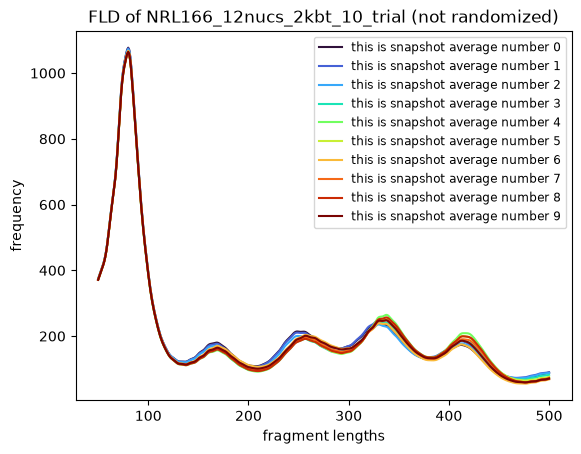

In [7]:

# nrl 166
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_1_trial.npy', 1 , 166 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_3_trial.npy', 3, 166)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_10_trial.npy', 10, 166)



(291, 451)
[[389.89081731 397.99740103 406.41294743 ...  77.6337594   77.75845497
   78.1094971 ]
 [390.7655277  398.95011105 407.47726477 ... 109.62989468 109.86997725
  110.25162484]
 [393.49610819 401.57664736 409.96137845 ...  93.49336483  93.86430506
   94.45679319]
 ...
 [392.95099662 401.21717492 409.83484368 ...  54.5239442   54.92000006
   55.44857792]
 [394.8699532  403.01364156 411.42193515 ...  80.35166247  80.60762494
   80.97707841]
 [396.11657471 404.57718226 413.32287739 ... 134.26266866 136.09074132
  137.98613926]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

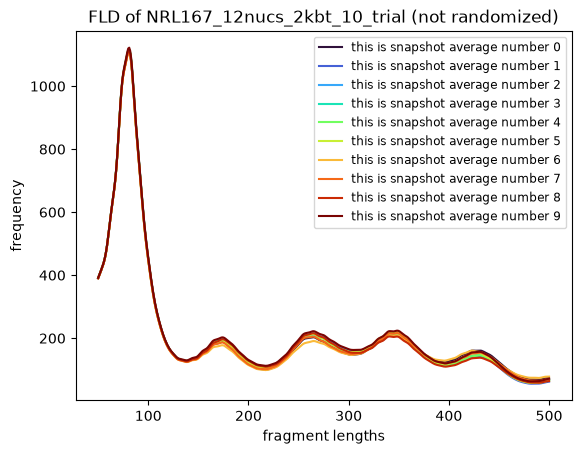

In [10]:
# nrl 167
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_1_trial.npy', 1 , 167 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_3_trial.npy', 3, 167)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_10_trial.npy', 10, 167)



(291, 451)
[[382.34501767 391.26670857 400.43794348 ...  60.92289609  61.24992114
   61.62551499]
 [382.74524456 391.74745819 400.98951508 ...  46.94538721  46.92613351
   47.00671658]
 [380.22916189 389.14795576 398.34319112 ...  53.80149533  53.92287967
   54.18603791]
 ...
 [381.37698753 390.41658722 399.76627504 ...  33.99751403  34.14454169
   34.35160358]
 [385.93154037 395.0457834  404.39832002 ...  59.84917182  59.83075531
   59.8612926 ]
 [385.38284899 394.42443555 403.78084501 ...  35.96625751  36.48424793
   37.04755785]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

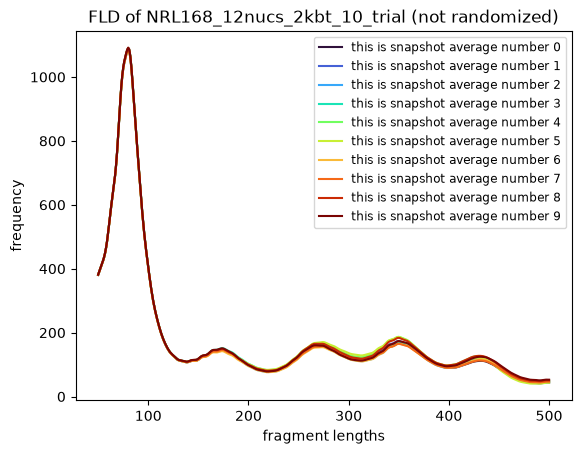

In [13]:
# nrl 168
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_1_trial.npy', 1 , 168 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_3_trial.npy', 3, 168)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_10_trial.npy', 10, 168)

